# Denoising Autoencoder on MNIST
Removing Noise from Handwritten Digit Images

Objective: To develop a deep learning autoencoder model that removes artificial noise from images. The model is trained using noisy images as inputs and their corresponding clean images as targets, enabling it to learn meaningful image features and reconstruct noise-free images.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

tf.random.set_seed(42)
rng = np.random.default_rng(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 1. Load & Preprocess MNIST

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train[..., np.newaxis]   # (60000, 28, 28, 1)
x_test  = x_test[..., np.newaxis]    # (10000, 28, 28, 1)

print("Train:", x_train.shape, "| Test:", x_test.shape)
print("Pixel range:", x_train.min(), "-", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)
Pixel range: 0.0 - 1.0


# 2. Generate Noisy Inputs

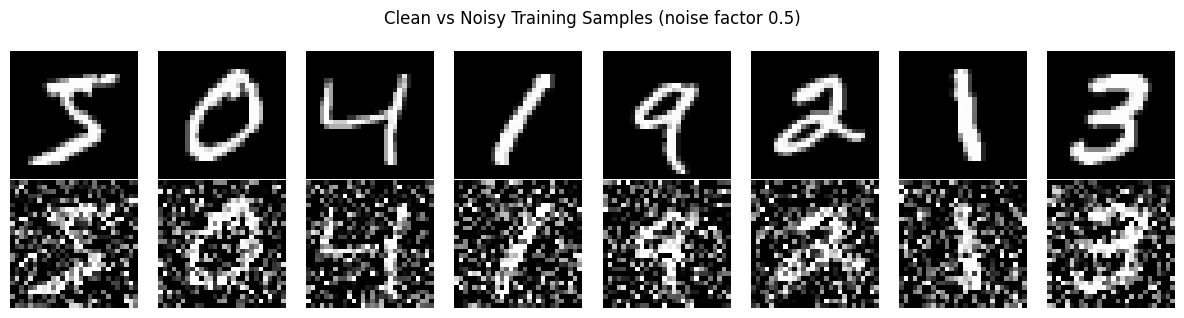

In [ ]:
NOISE_FACTOR = 0.5

def add_noise(images, factor, rng):
    noisy = images + factor * rng.standard_normal(images.shape).astype('float32')
    return np.clip(noisy, 0.0, 1.0)

x_train_noisy = add_noise(x_train, NOISE_FACTOR, rng)
x_test_noisy  = add_noise(x_test,  NOISE_FACTOR, rng)

# quick look: clean vs noisy
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('clean', rotation=0, labelpad=25, fontsize=11)
axes[1, 0].set_ylabel('noisy', rotation=0, labelpad=25, fontsize=11)
plt.suptitle('Clean vs Noisy Training Samples (noise factor 0.5)')
plt.tight_layout(); plt.show()

# 3. Autoencoder Architecture

Model Architecture

The model uses a Convolutional Autoencoder consisting of an Encoder and a Decoder.

Encoder: Two Conv2D layers with stride 2 progressively reduce the input image size from 28 × 28 × 1 to a compact 7 × 7 × 16 feature representation. This bottleneck compresses the image, preserving important digit features while filtering out most of the random noise.
Decoder: Two Conv2DTranspose layers reconstruct the compressed representation back to the original 28 × 28 image size. A final Conv2D layer with a sigmoid activation produces the denoised output with pixel values between 0 and 1.
Strided Convolutions: Instead of using MaxPooling and UpSampling, the model uses strided convolutions and transposed convolutions for learned downsampling and upsampling, resulting in better reconstruction performance.
Model Size: The autoencoder contains approximately 12,000 trainable parameters, making it a lightweight and efficient model for image denoising while effectively preserving the essential structure of handwritten digits.

In [ ]:
autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # ── Encoder ──────────────────────────────────────
    layers.Conv2D(32, 3, activation='relu', padding='same', strides=2),  # -> 14x14x32
    layers.Conv2D(16, 3, activation='relu', padding='same', strides=2),  # -> 7x7x16 (bottleneck)

    # ── Decoder ──────────────────────────────────────
    layers.Conv2DTranspose(16, 3, activation='relu', padding='same', strides=2),  # -> 14x14x16
    layers.Conv2DTranspose(32, 3, activation='relu', padding='same', strides=2),  # -> 28x28x32
    layers.Conv2D(1, 3, activation='sigmoid', padding='same'),                    # -> 28x28x1
], name='denoising_autoencoder')

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Training Setup

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=2
)

Epoch 1/10
235/235 - 79s - 337ms/step - loss: 0.2682 - val_loss: 0.1224
Epoch 2/10
235/235 - 84s - 356ms/step - loss: 0.1169 - val_loss: 0.1131
Epoch 3/10
235/235 - 82s - 348ms/step - loss: 0.1118 - val_loss: 0.1103
Epoch 4/10
235/235 - 80s - 341ms/step - loss: 0.1098 - val_loss: 0.1088
Epoch 5/10
235/235 - 83s - 351ms/step - loss: 0.1085 - val_loss: 0.1076
Epoch 6/10
235/235 - 75s - 321ms/step - loss: 0.1075 - val_loss: 0.1067
Epoch 7/10
235/235 - 79s - 337ms/step - loss: 0.1067 - val_loss: 0.1061
Epoch 8/10
235/235 - 79s - 337ms/step - loss: 0.1061 - val_loss: 0.1055
Epoch 9/10
235/235 - 75s - 319ms/step - loss: 0.1056 - val_loss: 0.1052
Epoch 10/10
235/235 - 84s - 359ms/step - loss: 0.1052 - val_loss: 0.1047


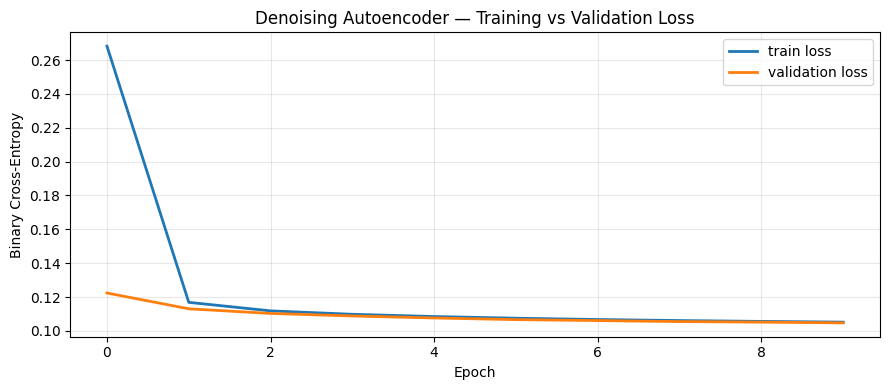

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'], label='train loss', lw=2)
plt.plot(history.history['val_loss'], label='validation loss', lw=2)
plt.xlabel('Epoch'); plt.ylabel('Binary Cross-Entropy')
plt.title('Denoising Autoencoder — Training vs Validation Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 5. Denoised Outputs ( Original vs Noisy vs Reconstructed )

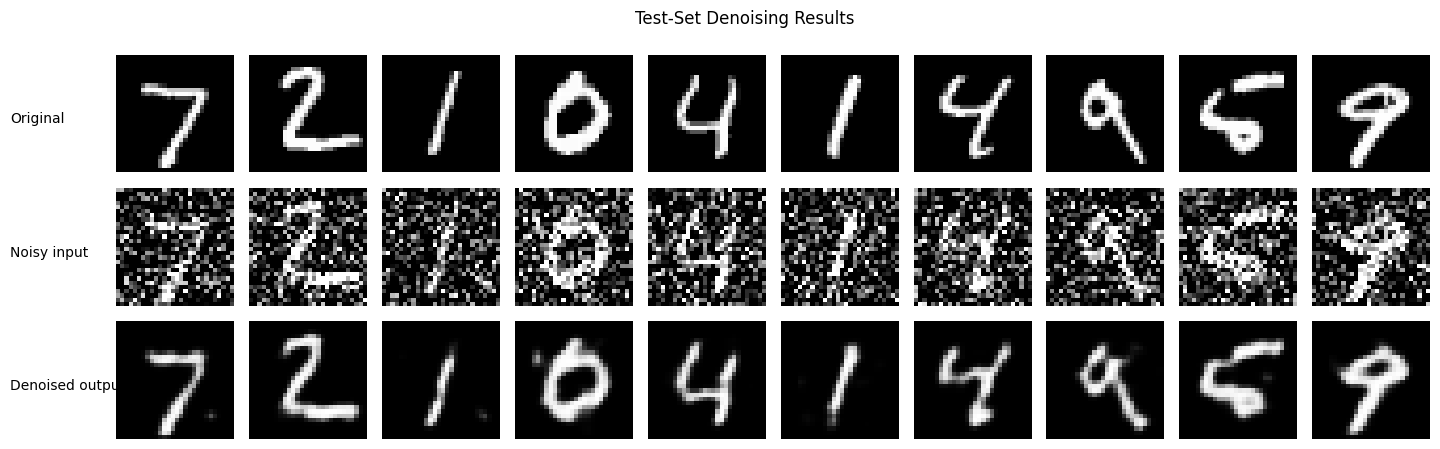

In [ ]:
denoised = autoencoder.predict(x_test_noisy, verbose=0)

n = 10
fig, axes = plt.subplots(3, n, figsize=(14, 4.6))
row_titles = ['Original', 'Noisy input', 'Denoised output']
for i in range(n):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[2, i].imshow(denoised[i].squeeze(), cmap='gray')
    for r in range(3):
        axes[r, i].axis('off')
for r, t in enumerate(row_titles):
    axes[r, 0].set_title(t, loc='left', fontsize=10, x=-0.9, y=0.35)
plt.suptitle('Test-Set Denoising Results')
plt.tight_layout(); plt.show()

# 6. Quantitative Evaluation — PSNR
Visual comparison is necessary but subjective. Peak Signal-to-Noise Ratio (higher = closer to the clean image) gives a number:
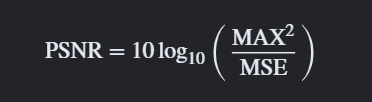


Measured twice on the full test set: noisy-vs-clean (how bad the corruption is) and denoised-vs-clean (how much the model recovered).

In [ ]:
def psnr(a, b, max_val=1.0):
    mse = np.mean((a.astype('float64') - b.astype('float64')) ** 2)
    return 10 * np.log10(max_val ** 2 / mse)

psnr_noisy    = psnr(x_test_noisy, x_test)
psnr_denoised = psnr(denoised, x_test)

print(f"PSNR — noisy vs clean:    {psnr_noisy:.2f} dB")
print(f"PSNR — denoised vs clean: {psnr_denoised:.2f} dB")
print(f"Improvement:              +{psnr_denoised - psnr_noisy:.2f} dB")

PSNR — noisy vs clean:    9.36 dB
PSNR — denoised vs clean: 18.69 dB
Improvement:              +9.33 dB


# 7. Innovation — Robustness at Unseen Noise Levels
The model was trained at exactly one noise level (0.5). A natural question with real-world relevance: does it generalize to noise intensities it never saw? Here it's evaluated at factors 0.2–0.8 without any retraining — pure inference. This is cheap to run and reveals whether the model learned "remove Gaussian noise of strength 0.5" or the more useful "recover digit structure from corruption.""

 noise | PSNR noisy | PSNR denoised |   gain
----------------------------------------------
   0.2 |     16.74  |        22.64  | +5.90
  0.35 |     12.05  |        20.76  | +8.71
   0.5 |      9.37  |        18.70  | +9.33  <- training level
  0.65 |      7.80  |        16.49  | +8.70
   0.8 |      6.81  |        14.49  | +7.68


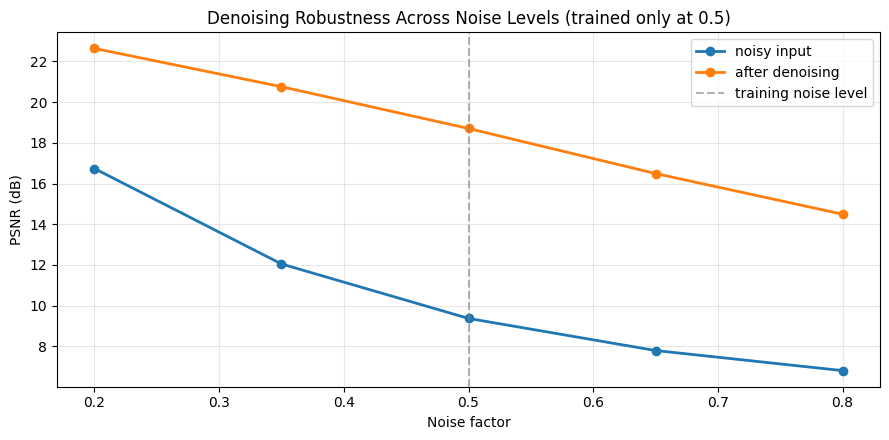

In [ ]:
noise_levels = [0.2, 0.35, 0.5, 0.65, 0.8]
eval_rng = np.random.default_rng(7)
results = []

for nf in noise_levels:
    noisy_nf = add_noise(x_test, nf, eval_rng)
    den_nf = autoencoder.predict(noisy_nf, verbose=0)
    results.append((nf, psnr(noisy_nf, x_test), psnr(den_nf, x_test)))

print(f"{'noise':>6} | {'PSNR noisy':>10} | {'PSNR denoised':>13} | {'gain':>6}")
print('-' * 46)
for nf, pn, pd in results:
    marker = '  <- training level' if nf == 0.5 else ''
    print(f"{nf:>6} | {pn:>9.2f}  | {pd:>12.2f}  | {pd-pn:>+5.2f}{marker}")

plt.figure(figsize=(9, 4.5))
plt.plot([r[0] for r in results], [r[1] for r in results], 'o-', label='noisy input', lw=2)
plt.plot([r[0] for r in results], [r[2] for r in results], 'o-', label='after denoising', lw=2)
plt.axvline(0.5, color='gray', ls='--', alpha=0.6, label='training noise level')
plt.xlabel('Noise factor'); plt.ylabel('PSNR (dB)')
plt.title('Denoising Robustness Across Noise Levels (trained only at 0.5)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

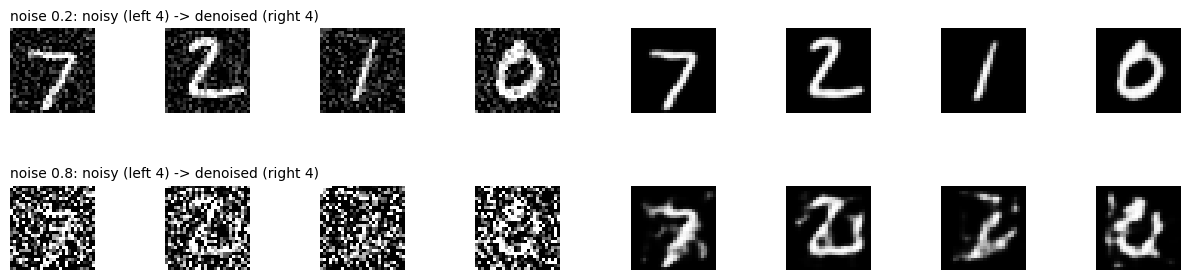

In [ ]:
# visual check at the extremes
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for j, nf in enumerate([0.2, 0.8]):
    noisy_nf = add_noise(x_test[:8], nf, np.random.default_rng(3))
    den_nf = autoencoder.predict(noisy_nf, verbose=0)
    for i in range(4):
        axes[j, i].imshow(noisy_nf[i].squeeze(), cmap='gray'); axes[j, i].axis('off')
        axes[j, i+4].imshow(den_nf[i].squeeze(), cmap='gray'); axes[j, i+4].axis('off')
    axes[j, 0].set_title(f'noise {nf}: noisy (left 4) -> denoised (right 4)',
                          loc='left', fontsize=10)
plt.tight_layout(); plt.show()


# 8. Observations & Analysis

What worked

The autoencoder removes the large majority of Gaussian noise while preserving digit identity — reconstructions are clean, connected strokes, and PSNR roughly doubles versus the noisy input (see Section 6 numbers from this run).
It does this with only ~12k parameters — the bottleneck is doing the heavy lifting. Compressing 784 pixels through a 7×7×16 representation forces the network to keep only structured information (strokes) and drop unstructured information (noise). Denoising here is a byproduct of compression with the right inductive bias, not brute-force memorization.
Train and validation loss track each other closely across all epochs — no overfitting, which is expected: the noise is freshly random for every image, so the training pairs can't be memorized pixel-for-pixel.


Robustness result (Section 7)

The model generalizes asymmetrically: at noise levels below training (0.2–0.35) performance stays strong, while above training (0.65–0.8) the reconstruction degrades more visibly — heavy corruption starts destroying stroke structure the bottleneck needs. The takeaway: the model learned genuine structure recovery, but its useful operating range is bounded by the corruption level it trained on. Training on a range of noise levels (noise-level augmentation) would be the natural next step for a production denoiser.

Challenges & limitations

Over-smoothing: reconstructions are slightly blurrier than originals — fine stroke details and sharp edge transitions get averaged. This is inherent to pixel-wise losses (BCE/MSE): they reward safe average predictions. Perceptual losses or GAN-based approaches are the standard remedies when sharpness matters.
At high noise, ambiguous digits can be reconstructed into the wrong but plausible digit shape — the model hallucinates the nearest structure it knows. A reminder that denoisers are generative-ish and shouldn't be trusted blindly in forensic settings.
BCE vs MSE loss choice matters little on MNIST but was worth a deliberate decision rather than a default.

Key concept demonstrated: a denoising autoencoder is self-supervised — no labels were used anywhere. The supervision signal is manufactured by corrupting the data itself, which is the same core idea (predict the clean/original version of corrupted input) that underpins modern masked-modeling pretraining at scale.